In [21]:
# UNZIP DATASET
!unzip archive.zip

# INSTALL LIBRARIES
!pip install torch torchvision scikit-learn matplotlib seaborn tqdm -q
print("Setup complete!")

Archive:  archive.zip
   creating: archive/
  inflating: archive/dataset.hdf5    
   creating: archive/Raw Data/
  inflating: archive/Raw Data/Data_details.txt  
  inflating: archive/Raw Data/data_gee.txt  
  inflating: archive/Raw Data/Data_labels.tif  
  inflating: archive/Raw Data/Mumbai_Data.tif  
  inflating: archive/Raw Data/mumbai_slum_cluster.kml  
  inflating: archive/sentinel_input.npy  
  inflating: archive/slum_labels.npy  
Setup complete!


In [22]:
import os
import copy
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)
from sklearn.utils.class_weight import compute_class_weight
from torch.utils.data import Dataset, DataLoader

In [23]:
# SET RANDOM SEED
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

# DEVICE
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [24]:
# LOAD DATASET
try:
    X = np.load("/content/archive/sentinel_input.npy")
    y = np.load("/content/archive/slum_labels.npy")
    print("Satellite image shape:", X.shape)
    print("Label mask shape:", y.shape)
except FileNotFoundError:
    print("Error: Data files not found. Please upload archive.zip")
    # Create dummy data for testing
    X = np.random.rand(13, 256, 256).astype(np.float32)
    y = np.random.randint(0, 2, (256, 256)).astype(np.float32)

Satellite image shape: (4, 3954, 2105)
Label mask shape: (3954, 2105)


Channels: 4


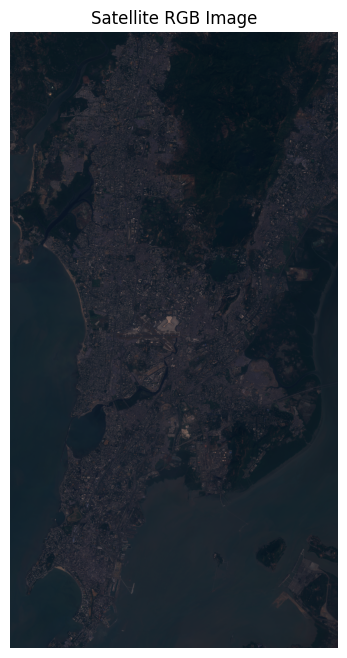

In [25]:
# CHECK NUMBER OF CHANNELS
channels, height, width = X.shape
print("Channels:", channels)

if channels < 3:
    raise ValueError("The satellite image needs at least 3 channels for RGB visualization.")

# VISUALIZE RGB SATELLITE IMAGE
rgb = np.stack([X[0], X[1], X[2]], axis=2)
rgb = (rgb - rgb.min()) / (rgb.max() - rgb.min() + 1e-8)

plt.figure(figsize=(8, 8))
plt.imshow(rgb)
plt.title("Satellite RGB Image")
plt.axis("off")
plt.show()

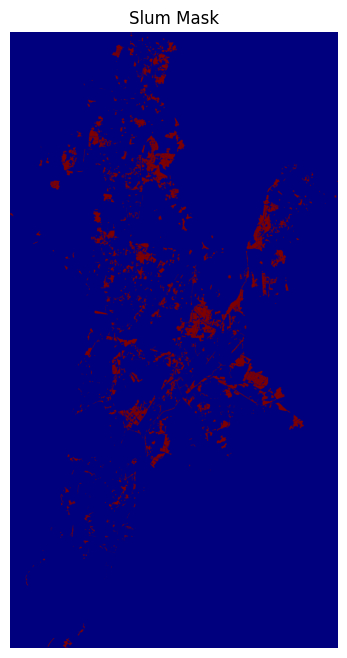

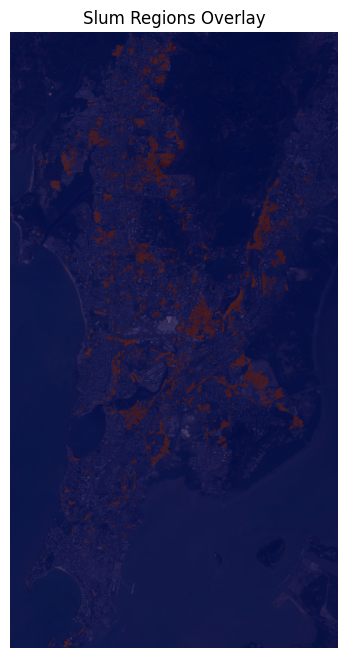

In [26]:
# VISUALIZE SLUM MASK
plt.figure(figsize=(8, 8))
plt.imshow(y, cmap="jet")
plt.title("Slum Mask")
plt.axis("off")
plt.show()

# OVERLAY LABELS
plt.figure(figsize=(8, 8))
plt.imshow(rgb)
plt.imshow(y, cmap="jet", alpha=0.35)
plt.title("Slum Regions Overlay")
plt.axis("off")
plt.show()

In [27]:
# GENERATE PATCHES
patch_size = 64
stride = 64
slum_threshold = 0.01
X_patches = []
y_patches = []

for i in range(0, height - patch_size + 1, stride):
    for j in range(0, width - patch_size + 1, stride):
        patch = X[:, i:i+patch_size, j:j+patch_size]
        label_patch = y[i:i+patch_size, j:j+patch_size]
        label = 1 if np.mean(label_patch) > slum_threshold else 0
        X_patches.append(patch)
        y_patches.append(label)

X_patches = np.array(X_patches, dtype=np.float32)
y_patches = np.array(y_patches, dtype=np.int64)

print("Patch dataset shape:", X_patches.shape)
print("Patch labels shape:", y_patches.shape)

Patch dataset shape: (1952, 4, 64, 64)
Patch labels shape: (1952,)


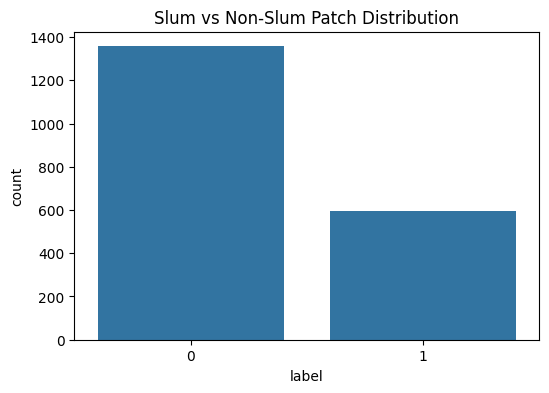

label
0    1357
1     595
Name: count, dtype: int64


In [28]:
# DATASET DISTRIBUTION
df = pd.DataFrame({"label": y_patches})

plt.figure(figsize=(6, 4))
sns.countplot(x="label", data=df)
plt.title("Slum vs Non-Slum Patch Distribution")
plt.show()

print(df["label"].value_counts())

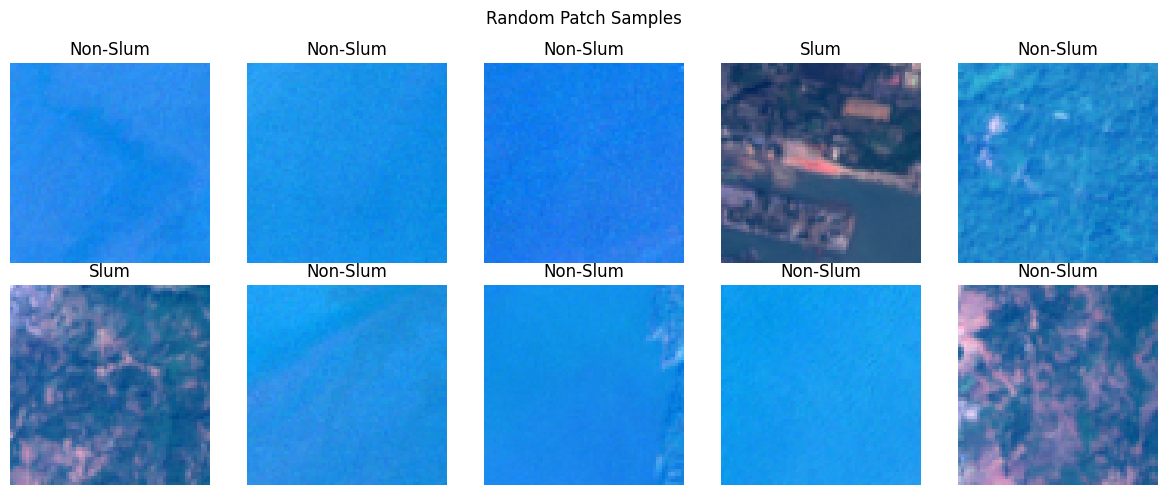

In [29]:
# VISUALIZE PATCH SAMPLES
indices = np.random.choice(len(X_patches), min(10, len(X_patches)), replace=False)
fig, axes = plt.subplots(2, 5, figsize=(12, 5))

for ax, idx in zip(axes.flat, indices):
    patch_rgb = np.stack([
        X_patches[idx][0],
        X_patches[idx][1],
        X_patches[idx][2]
    ], axis=2)
    patch_rgb = (patch_rgb - patch_rgb.min()) / (patch_rgb.max() - patch_rgb.min() + 1e-8)

    label_name = "Slum" if y_patches[idx] == 1 else "Non-Slum"

    ax.imshow(patch_rgb)
    ax.set_title(label_name)
    ax.axis("off")

plt.suptitle("Random Patch Samples")
plt.tight_layout()
plt.show()

In [30]:
# TRAIN / VALIDATION / TEST SPLIT
X_train, X_temp, y_train, y_temp = train_test_split(
    X_patches, y_patches, test_size=0.30, random_state=42, stratify=y_patches)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp)

print("Train set:", X_train.shape, y_train.shape)
print("Validation set:", X_val.shape, y_val.shape)
print("Test set:", X_test.shape, y_test.shape)

Train set: (1366, 4, 64, 64) (1366,)
Validation set: (293, 4, 64, 64) (293,)
Test set: (293, 4, 64, 64) (293,)


In [31]:
# NORMALIZE USING TRAIN SET ONLY
train_mean = np.mean(X_train, axis=(0, 2, 3), keepdims=True)
train_std = np.std(X_train, axis=(0, 2, 3), keepdims=True) + 1e-8

X_train = (X_train - train_mean) / train_std
X_val   = (X_val   - train_mean) / train_std
X_test  = (X_test  - train_mean) / train_std

print("Normalization complete.")

Normalization complete.


In [32]:
# CREATE DATASET CLASS
class SlumDataset(Dataset):
    def __init__(self, images, labels):
        self.images = torch.tensor(images, dtype=torch.float32)
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        return self.images[idx], self.labels[idx]

In [33]:
# CREATE DATALOADERS
batch_size = 16

train_dataset = SlumDataset(X_train, y_train)
val_dataset   = SlumDataset(X_val, y_val)
test_dataset  = SlumDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print("DataLoaders created successfully!")

DataLoaders created successfully!


In [34]:
# HANDLE CLASS IMBALANCE
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)

weights = torch.tensor(class_weights, dtype=torch.float32).to(device)
criterion = nn.CrossEntropyLoss(weight=weights)

print("Class weights:", class_weights)

Class weights: [0.71894737 1.64182692]


In [35]:
# BASELINE CNN MODEL
class BaselineCNN(nn.Module):
    def __init__(self, in_channels):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(), nn.MaxPool2d(2)
        )
        self.fc = nn.Sequential(
            nn.Linear(128 * 8 * 8, 128), nn.ReLU(), nn.Dropout(0.3), nn.Linear(128, 2)
        )

    def forward(self, x):
        x = self.conv(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)
        return x

print("Baseline CNN model defined!")

Baseline CNN model defined!


In [36]:
# MIXTURE OF EXPERTS MODEL
class Expert(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256), nn.ReLU(), nn.Dropout(0.3), nn.Linear(256, 2)
        )
    def forward(self, x):
        return self.net(x)

class GatingNetwork(nn.Module):
    def __init__(self, input_dim, num_experts):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128), nn.ReLU(), nn.Linear(128, num_experts)
        )
    def forward(self, x):
        return torch.softmax(self.net(x), dim=1)

class MoEModel(nn.Module):
    def __init__(self, in_channels, num_experts=3):
        super().__init__()
        self.feature_extractor = nn.Sequential(
            nn.Conv2d(in_channels, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(), nn.MaxPool2d(2)
        )
        self.flatten_dim = 128 * 8 * 8
        self.experts = nn.ModuleList([Expert(self.flatten_dim) for _ in range(num_experts)])
        self.gate = GatingNetwork(self.flatten_dim, num_experts)

    def forward(self, x):
        x = self.feature_extractor(x)
        x = torch.flatten(x, 1)
        gate_weights = self.gate(x)
        expert_outputs = torch.stack([expert(x) for expert in self.experts], dim=1)
        gate_weights = gate_weights.unsqueeze(-1)
        output = torch.sum(expert_outputs * gate_weights, dim=1)
        return output

print("Mixture of Experts model defined!")

Mixture of Experts model defined!


In [37]:
# TRAIN FUNCTION
def train_model(model, train_loader, val_loader, criterion, epochs=25, lr=1e-3, patience=5):
    model = model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)

    history = {
        "train_loss": [],
        "val_loss": [],
        "train_acc": [],
        "val_acc": []}

    best_model = copy.deepcopy(model.state_dict())
    best_val_loss = float("inf")
    patience_counter = 0

    for epoch in range(epochs):
        # TRAIN
        model.train()
        running_loss = 0
        train_preds, train_labels = [], []

        for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}"):
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
            preds = torch.argmax(outputs, dim=1)
            train_preds.extend(preds.cpu().numpy())
            train_labels.extend(labels.cpu().numpy())

        train_loss = running_loss / len(train_loader)
        train_acc = accuracy_score(train_labels, train_preds)

        # VALIDATION
        model.eval()
        val_loss_total = 0
        val_preds, val_labels = [], []

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss_total += loss.item()
                preds = torch.argmax(outputs, dim=1)
                val_preds.extend(preds.cpu().numpy())
                val_labels.extend(labels.cpu().numpy())

        val_loss = val_loss_total / len(val_loader)
        val_acc = accuracy_score(val_labels, val_preds)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        print(f"\nEpoch {epoch+1}")
        print(f"Train Loss: {round(train_loss,4)}, Train Acc: {round(train_acc,4)}")
        print(f"Val Loss: {round(val_loss,4)}, Val Acc: {round(val_acc,4)}")

        # EARLY STOPPING
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model = copy.deepcopy(model.state_dict())
            patience_counter = 0
            print("✓ Best model saved")
        else:
            patience_counter += 1
            print(f"✗ No improvement: {patience_counter}")

        if patience_counter >= patience:
            print("Early stopping triggered")
            break

    model.load_state_dict(best_model)
    return model, history

print("Training function defined!")

Training function defined!


In [38]:
# EVALUATION FUNCTION
def evaluate_model(model, loader, model_name="Model"):
    model.eval()
    y_true, y_pred = [], []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            outputs = model(images)
            preds = torch.argmax(outputs, dim=1)
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())

    acc = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)

    print(f"\n{model_name}")
    print(f"Accuracy: {acc:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print("\nClassification Report\n")
    print(classification_report(y_true, y_pred))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure()
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(model_name + " Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    return {
        "accuracy": acc,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

print("Evaluation function defined!")

Evaluation function defined!


In [39]:
# TRAIN BASELINE CNN

print("Training Baseline CNN...")

in_channels = channels
baseline_model = BaselineCNN(in_channels)
baseline_model, baseline_history = train_model(
    model=baseline_model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    epochs=25,
    lr=1e-3,
    patience=5)

Training Baseline CNN...


Epoch 1/25: 100%|██████████| 86/86 [00:01<00:00, 63.35it/s]



Epoch 1
Train Loss: 0.6967, Train Acc: 0.8111
Val Loss: 0.3519, Val Acc: 0.8532
✓ Best model saved


Epoch 2/25: 100%|██████████| 86/86 [00:00<00:00, 123.81it/s]



Epoch 2
Train Loss: 0.3736, Train Acc: 0.8258
Val Loss: 0.3074, Val Acc: 0.8567
✓ Best model saved


...


Epoch 14
Train Loss: 0.2896, Train Acc: 0.8507
Val Loss: 0.3126, Val Acc: 0.8635
✗ No improvement: 3


Epoch 15/25: 100%|██████████| 86/86 [00:00<00:00, 223.06it/s]



Epoch 15
Train Loss: 0.264, Train Acc: 0.8602
Val Loss: 0.2978, Val Acc: 0.8601
✗ No improvement: 4


Epoch 16/25: 100%|██████████| 86/86 [00:00<00:00, 224.36it/s]



Epoch 16
Train Loss: 0.2517, Train Acc: 0.8682
Val Loss: 0.3561, Val Acc: 0.8601
✗ No improvement: 5
Early stopping triggered


In [40]:
# TRAIN MIXTURE OF EXPERTS
print("Training Mixture of Experts...")

moe_model = MoEModel(in_channels, num_experts=3)
moe_model, moe_history = train_model(
    model=moe_model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    epochs=25,
    lr=1e-3,
    patience=5)

Training Mixture of Experts...


Epoch 1/25: 100%|██████████| 86/86 [00:00<00:00, 120.38it/s]



Epoch 1
Train Loss: 0.7978, Train Acc: 0.7921
Val Loss: 0.3613, Val Acc: 0.8498
✓ Best model saved


Epoch 2/25: 100%|██████████| 86/86 [00:00<00:00, 127.50it/s]



Epoch 2
Train Loss: 0.4028, Train Acc: 0.8192
Val Loss: 0.341, Val Acc: 0.8498
✓ Best model saved


...


Epoch 13
Train Loss: 0.2966, Train Acc: 0.8668
Val Loss: 0.3393, Val Acc: 0.8464
✗ No improvement: 3


Epoch 14/25: 100%|██████████| 86/86 [00:00<00:00, 128.73it/s]



Epoch 14
Train Loss: 0.2533, Train Acc: 0.8829
Val Loss: 0.3321, Val Acc: 0.8567
✗ No improvement: 4


Epoch 15/25: 100%|██████████| 86/86 [00:00<00:00, 128.26it/s]


Epoch 15
Train Loss: 0.2669, Train Acc: 0.8799
Val Loss: 0.323, Val Acc: 0.8635
✗ No improvement: 5
Early stopping triggered


Evaluating Models on Test Set...

Baseline CNN
Accuracy: 0.8020
Precision: 0.6260
Recall: 0.8652
F1 Score: 0.7264

Classification Report

              precision    recall  f1-score   support

           0       0.93      0.77      0.84       204
           1       0.63      0.87      0.73        89

    accuracy                           0.80       293
   macro avg       0.78      0.82      0.79       293
weighted avg       0.84      0.80      0.81       293



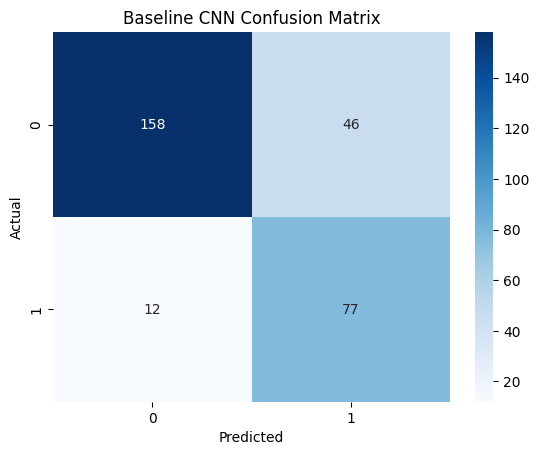


Mixture of Experts
Accuracy: 0.8294
Precision: 0.6822
Recall: 0.8202
F1 Score: 0.7449

Classification Report

              precision    recall  f1-score   support

           0       0.91      0.83      0.87       204
           1       0.68      0.82      0.74        89

    accuracy                           0.83       293
   macro avg       0.80      0.83      0.81       293
weighted avg       0.84      0.83      0.83       293



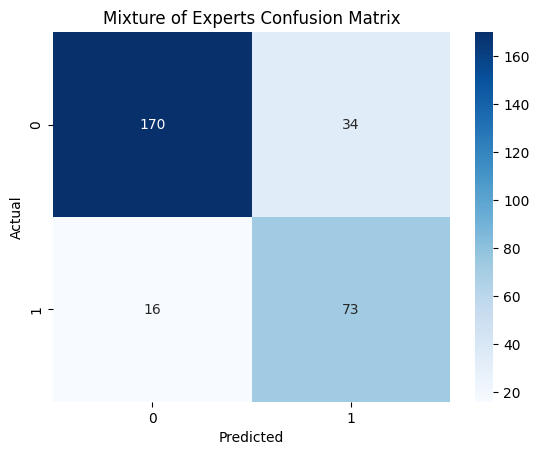

In [41]:
# EVALUATE BOTH MODELS ON TEST SET

print("Evaluating Models on Test Set...")

baseline_metrics = evaluate_model(baseline_model, test_loader, "Baseline CNN")
moe_metrics = evaluate_model(moe_model, test_loader, "Mixture of Experts")

In [42]:
# MONTE CARLO DROPOUT INFERENCE FOR UNCERTAINTY ESTIMATION

import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt

def enable_dropout(model):
    """Enable dropout layers during test-time."""
    for m in model.modules():
        if isinstance(m, nn.Dropout):
            m.train()

def mc_dropout_predict(model, loader, mc_passes=20):
    model.eval()
    enable_dropout(model)

    all_true = []
    all_pred = []
    all_confidence = []
    all_uncertainty = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)

            mc_probs = []

            for _ in range(mc_passes):
                outputs = model(images)
                probs = F.softmax(outputs, dim=1)
                mc_probs.append(probs.unsqueeze(0))

            mc_probs = torch.cat(mc_probs, dim=0)   # [mc_passes, batch, classes]
            mean_probs = mc_probs.mean(dim=0)       # [batch, classes]
            var_probs = mc_probs.var(dim=0)         # [batch, classes]

            preds = torch.argmax(mean_probs, dim=1)
            confidence = torch.max(mean_probs, dim=1).values
            uncertainty = var_probs.mean(dim=1)     # average predictive variance

            all_true.extend(labels.numpy())
            all_pred.extend(preds.cpu().numpy())
            all_confidence.extend(confidence.cpu().numpy())
            all_uncertainty.extend(uncertainty.cpu().numpy())

    return {
        "y_true": np.array(all_true),
        "y_pred": np.array(all_pred),
        "confidence": np.array(all_confidence),
        "uncertainty": np.array(all_uncertainty)
    }

mc_results = mc_dropout_predict(moe_model, test_loader, mc_passes=20)

print("MC Dropout inference completed.")
print("Average confidence:", mc_results["confidence"].mean())
print("Average uncertainty:", mc_results["uncertainty"].mean())

MC Dropout inference completed.
Average confidence: 0.8602541
Average uncertainty: 0.003221157


UA-MoE (MC Dropout)
Accuracy: 0.8259
Precision: 0.6759
Recall: 0.8202
F1 Score: 0.7411

Classification Report

              precision    recall  f1-score   support

           0       0.91      0.83      0.87       204
           1       0.68      0.82      0.74        89

    accuracy                           0.83       293
   macro avg       0.79      0.82      0.81       293
weighted avg       0.84      0.83      0.83       293



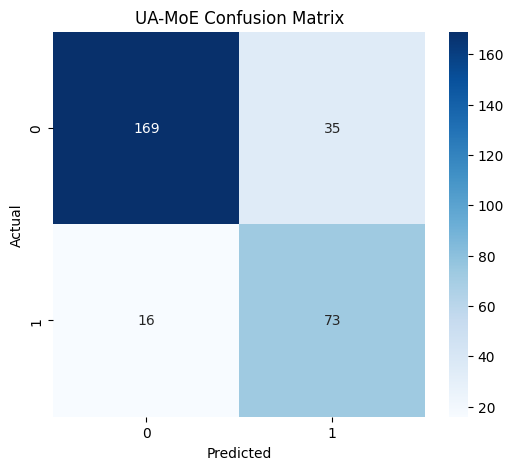

Average uncertainty (correct predictions): 0.003069721
Average uncertainty (incorrect predictions): 0.003939738


In [48]:
# UA-MOE EVALUATION

y_true = mc_results["y_true"]
y_pred = mc_results["y_pred"]
uncertainty = mc_results["uncertainty"]

acc = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, zero_division=0)
recall = recall_score(y_true, y_pred, zero_division=0)
f1 = f1_score(y_true, y_pred, zero_division=0)

print("UA-MoE (MC Dropout)")
print(f"Accuracy: {acc:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print("\nClassification Report\n")
print(classification_report(y_true, y_pred))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("UA-MoE Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

correct_mask = (y_true == y_pred)
incorrect_mask = (y_true != y_pred)

print("Average uncertainty (correct predictions):", uncertainty[correct_mask].mean())
print("Average uncertainty (incorrect predictions):", uncertainty[incorrect_mask].mean())

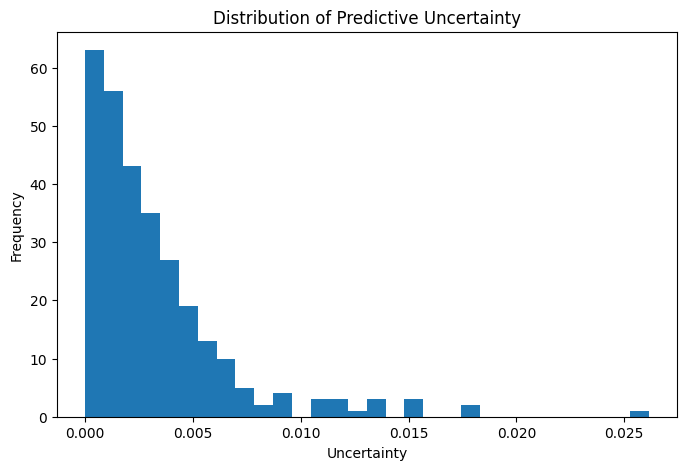

In [49]:
# UNCERTAINTY DISTRIBUTION

plt.figure(figsize=(8,5))
plt.hist(mc_results["uncertainty"], bins=30)
plt.title("Distribution of Predictive Uncertainty")
plt.xlabel("Uncertainty")
plt.ylabel("Frequency")
plt.show()

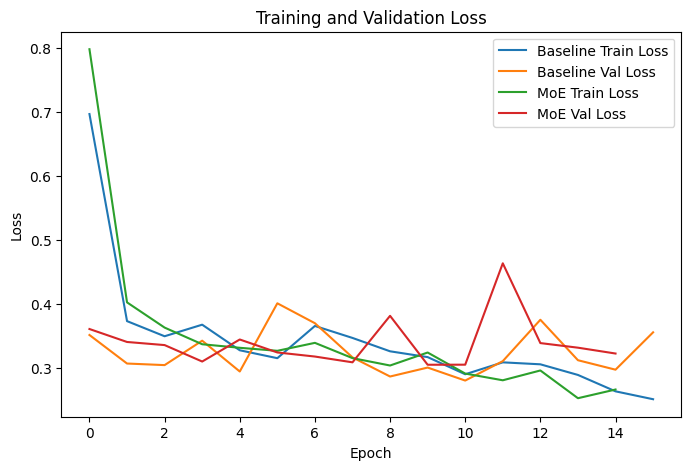

In [43]:
# PLOT LOSS CURVES
plt.figure(figsize=(8, 5))
plt.plot(baseline_history["train_loss"], label="Baseline Train Loss")
plt.plot(baseline_history["val_loss"], label="Baseline Val Loss")
plt.plot(moe_history["train_loss"], label="MoE Train Loss")
plt.plot(moe_history["val_loss"], label="MoE Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.show()

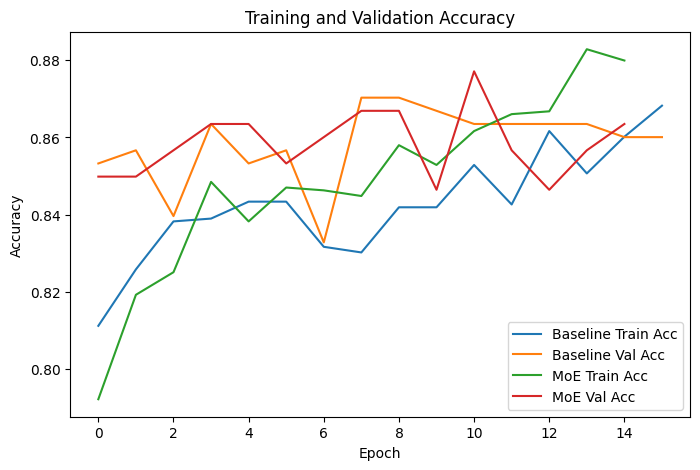

In [44]:
# PLOT ACCURACY CURVES
plt.figure(figsize=(8, 5))
plt.plot(baseline_history["train_acc"], label="Baseline Train Acc")
plt.plot(baseline_history["val_acc"], label="Baseline Val Acc")
plt.plot(moe_history["train_acc"], label="MoE Train Acc")
plt.plot(moe_history["val_acc"], label="MoE Val Acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.show()

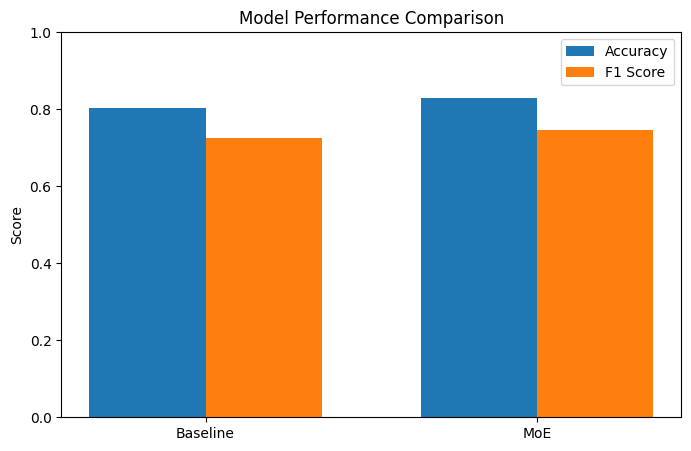

In [45]:
# MODEL COMPARISON BAR CHART
models = ["Baseline", "MoE"]
accuracy_scores = [baseline_metrics["accuracy"], moe_metrics["accuracy"]]
f1_scores = [baseline_metrics["f1"], moe_metrics["f1"]]
x = np.arange(len(models))
width = 0.35

plt.figure(figsize=(8, 5))
plt.bar(x - width/2, accuracy_scores, width, label="Accuracy")
plt.bar(x + width/2, f1_scores, width, label="F1 Score")
plt.xticks(x, models)
plt.ylim(0, 1)
plt.ylabel("Score")
plt.title("Model Performance Comparison")
plt.legend()
plt.show()

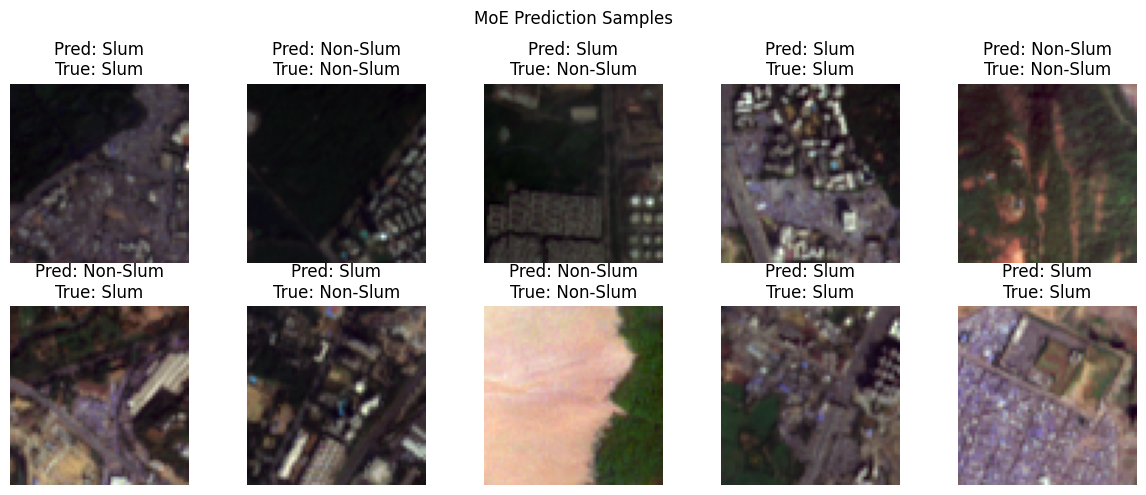

In [46]:
# VISUALIZE SAMPLE PREDICTIONS USING MOE MODEL
moe_model.eval()
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
sample_indices = np.random.choice(len(X_test), size=min(10, len(X_test)), replace=False)

for ax, idx in zip(axes.flat, sample_indices):
    img = X_test[idx]
    label_true = y_test[idx]
    tensor = torch.tensor(img, dtype=torch.float32).unsqueeze(0).to(device)

    with torch.no_grad():
        output = moe_model(tensor)
        pred = torch.argmax(output, dim=1).item()

    patch_rgb = np.stack([img[0], img[1], img[2]], axis=2)
    patch_rgb = (patch_rgb - patch_rgb.min()) / (patch_rgb.max() - patch_rgb.min() + 1e-8)

    pred_name = "Slum" if pred == 1 else "Non-Slum"
    true_name = "Slum" if label_true == 1 else "Non-Slum"

    ax.imshow(patch_rgb)
    ax.set_title(f"Pred: {pred_name}\nTrue: {true_name}")
    ax.axis("off")

plt.suptitle("MoE Prediction Samples")
plt.tight_layout()
plt.show()

In [47]:
# SAVE BEST MODEL
torch.save(moe_model.state_dict(), "moe_slum_model.pth")
print("MoE model saved successfully as moe_slum_model.pth")

# SAVE TRAINING METRICS
results_df = pd.DataFrame({
    "Model": ["Baseline CNN", "Mixture of Experts"],
    "Accuracy": [baseline_metrics["accuracy"], moe_metrics["accuracy"]],
    "Precision": [baseline_metrics["precision"], moe_metrics["precision"]],
    "Recall": [baseline_metrics["recall"], moe_metrics["recall"]],
    "F1 Score": [baseline_metrics["f1"], moe_metrics["f1"]]
})

print("FINAL RESULTS")
print(results_df)

results_df.to_csv("model_results.csv", index=False)
print("\nResults saved as model_results.csv")

MoE model saved successfully as moe_slum_model.pth
FINAL RESULTS
                Model  Accuracy  Precision    Recall  F1 Score
0        Baseline CNN  0.802048   0.626016  0.865169  0.726415
1  Mixture of Experts  0.829352   0.682243  0.820225  0.744898

Results saved as model_results.csv
